# 03 - Modelado Supervisado
## Prediccion de produccion de petroleo (Vaca Muerta / YPF)

**Objetivo:** predecir cuanto petroleo (`prod_pet`) va a producir un pozo en un
mes dado, usando como pistas: cuanto produjo el mes anterior, la antiguedad
del pozo, la profundidad, la formacion y la cuenca.

**Como evaluamos:** separamos los datos por tiempo (no al azar), para simular
una situacion real: entrenamos con anios viejos y probamos con anios nuevos
que el modelo nunca vio.

In [1]:
import sys
import os

sys.path.append("..")

if os.getcwd().endswith("notebooks"):
    os.chdir("..")

print("Carpeta de trabajo actual:", os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

sns.set_theme(style="whitegrid")
%matplotlib inline

Carpeta de trabajo actual: /Users/cristianaguilera/Desktop/proyecto-final-data-science


## Paso 1: Cargar el dataset con las variables ya creadas

Este archivo lo generamos en el notebook 02, ya tiene todas las columnas
nuevas (antiguedad, lag, declinacion, ratio, acumulada, codigos).

In [2]:
df = pd.read_csv("data/processed/produccion_con_features.csv")
print(df.shape)
df.head()

(421046, 49)


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,...,antiguedad_meses,prod_pet_mes_anterior,prod_gas_mes_anterior,declinacion_pet,declinacion_gas,ratio_gas_petroleo,prod_pet_acumulada,prod_gas_acumulada,formacion_cod,cuenca_cod
0,PEL,2006,2,3640,0.000,0.000,0.000,0.0,0.0,0.0,...,1,NaN,NaN,NaN,NaN,NaN,0.000,0.000,27,2
1,PEL,2006,3,3640,30.808,1.731,30.570,0.0,0.0,0.0,...,2,0.000,0.000,NaN,NaN,0.056187,30.808,1.731,27,2
2,PEL,2006,4,3640,76.609,3.713,46.479,0.0,0.0,0.0,...,3,30.808,1.731,1.486659,1.145003,0.048467,107.417,5.444,27,2
3,PEL,2006,5,3640,63.273,4.202,50.536,0.0,0.0,0.0,...,4,76.609,3.713,-0.174079,0.131699,0.066411,170.690,9.646,27,2
4,PEL,2006,6,3640,55.043,4.373,52.062,0.0,0.0,0.0,...,5,63.273,4.202,-0.130071,0.040695,0.079447,225.733,14.019,27,2


## Paso 2: Elegir las columnas que va a usar el modelo

`X` son las pistas (features) que le damos al modelo.
`y` es lo que queremos predecir (la produccion de petroleo de ese mes).

In [3]:
columnas_features = [
    "antiguedad_meses",
    "prod_pet_mes_anterior",
    "prod_gas_mes_anterior",
    "ratio_gas_petroleo",
    "profundidad",
    "formacion_cod",
    "cuenca_cod",
]
columna_objetivo = "prod_pet"

print("Features:", columnas_features)
print("Objetivo:", columna_objetivo)

Features: ['antiguedad_meses', 'prod_pet_mes_anterior', 'prod_gas_mes_anterior', 'ratio_gas_petroleo', 'profundidad', 'formacion_cod', 'cuenca_cod']
Objetivo: prod_pet


## Paso 3: Sacar las filas que no sirven para entrenar

- El primer mes de cada pozo no tiene "mes anterior", asi que esa fila
  queda con NaN y no se puede usar para entrenar.
- El anio 2026 esta incompleto (lo marcamos en el preprocesamiento), asi
  que tampoco lo usamos todavia.

In [4]:
df_modelo = df[df["anio_completo"]].copy()
df_modelo = df_modelo.dropna(subset=columnas_features + [columna_objetivo])

print("Filas antes de filtrar:", len(df))
print("Filas listas para entrenar:", len(df_modelo))

Filas antes de filtrar: 421046
Filas listas para entrenar: 245942


## Paso 4: Separar en entrenamiento (train) y prueba (test) por anio

En vez de mezclar todo al azar, usamos anios viejos para entrenar y
anios nuevos para probar - asi simulamos una situacion real, donde el
modelo tiene que predecir el futuro, no el pasado.

In [5]:
anio_corte = 2024  # entrenamos con todo lo anterior a este anio

train = df_modelo[df_modelo["anio"] < anio_corte]
test = df_modelo[df_modelo["anio"] >= anio_corte]

X_train = train[columnas_features]
y_train = train[columna_objetivo]

X_test = test[columnas_features]
y_test = test[columna_objetivo]

print("Filas de entrenamiento:", len(X_train))
print("Filas de prueba:", len(X_test))

Filas de entrenamiento: 177686
Filas de prueba: 68256


## Paso 5: Entrenar el modelo

Usamos XGBoost, un modelo de tipo "arbol de decision" muy usado para
este tipo de problemas (datos en tabla, con relaciones no lineales).

In [6]:
modelo = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
)

modelo.fit(X_train, y_train)
print("Modelo entrenado")

Modelo entrenado


## Paso 6: Ver que tan bien predice

Le pedimos al modelo que prediga sobre los datos de prueba (que nunca vio)
y comparamos con los valores reales usando tres metricas:

- **MAE** (error promedio en las mismas unidades que `prod_pet`, mas facil de interpretar)
- **RMSE** (parecido al MAE, pero castiga mas fuerte los errores grandes)
- **R2** (que tan bien explica el modelo la variacion de los datos, de 0 a 1, mas cerca de 1 es mejor)

In [7]:
predicciones = modelo.predict(X_test)

mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))
r2 = r2_score(y_test, predicciones)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.3f}")

MAE:  195.11
RMSE: 520.31
R2:   0.853


## Paso 7: Grafico de valores reales vs predichos

Si el modelo predijera perfecto, todos los puntos caerian sobre la linea
diagonal. Cuanto mas dispersos esten los puntos respecto a esa linea,
peor esta prediciendo.

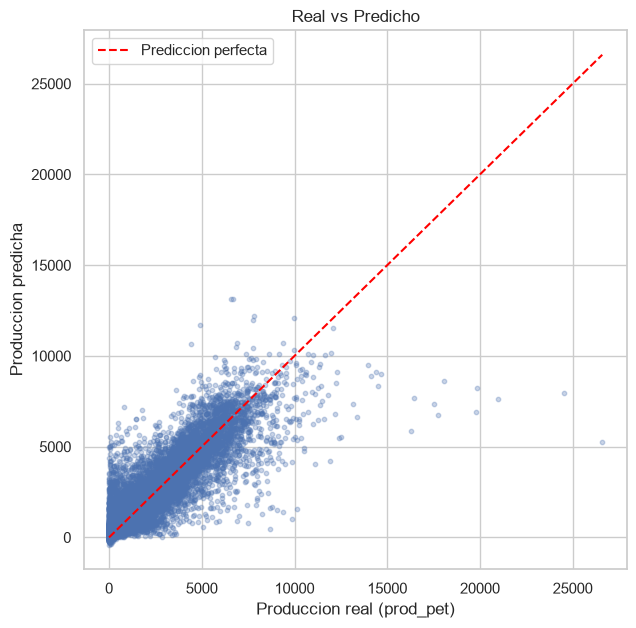

In [8]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, predicciones, alpha=0.3, s=10)

valor_max = max(y_test.max(), predicciones.max())
plt.plot([0, valor_max], [0, valor_max], color="red", linestyle="--", label="Prediccion perfecta")

plt.xlabel("Produccion real (prod_pet)")
plt.ylabel("Produccion predicha")
plt.title("Real vs Predicho")
plt.legend()
plt.show()

## Paso 8: Que variables usa mas el modelo (importancia de features)

Nos muestra que tan importante fue cada variable para las predicciones
del modelo. Es un primer acercamiento a la explicabilidad - mas adelante
se puede profundizar con SHAP.

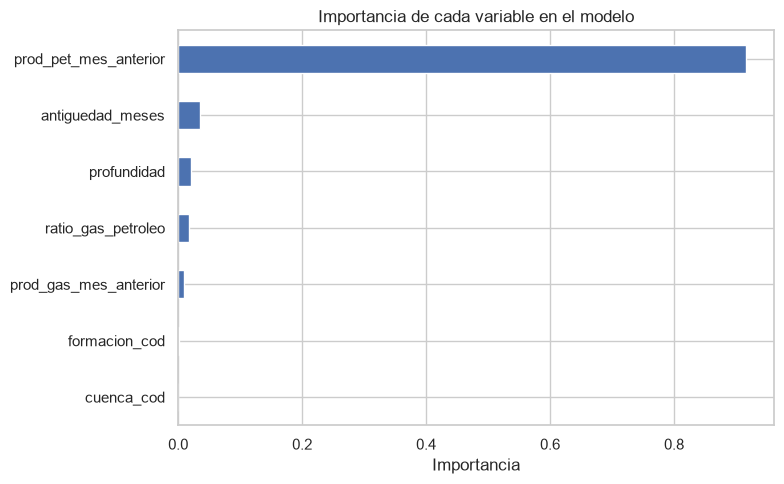

In [9]:
importancias = pd.Series(modelo.feature_importances_, index=columnas_features)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importancias.plot(kind="barh", color="#4C72B0")
plt.title("Importancia de cada variable en el modelo")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

## Paso 9: Guardar el modelo entrenado

Lo guardamos en `models/` para poder usarlo despues en la API
(`api/app.py`) sin tener que reentrenarlo cada vez.

In [10]:
os.makedirs("models", exist_ok=True)
joblib.dump(modelo, "models/modelo_produccion_pet.joblib")
print("Modelo guardado en models/modelo_produccion_pet.joblib")

Modelo guardado en models/modelo_produccion_pet.joblib


## Conclusiones

- El modelo se entreno con datos hasta 2023 y se probo con 2024-2025
  (datos que nunca vio durante el entrenamiento).
- Las metricas (MAE, RMSE, R2) quedan documentadas arriba - hay que
  completarlas con los valores reales una vez que se corra el notebook.
- El grafico de real vs predicho y la importancia de variables dan una
  primera idea de que tan bien esta funcionando el modelo y en que se basa.

**Proximo paso:** `04_modelado_no_supervisado_dl.ipynb` - agrupar pozos
segun su curva de produccion usando K-Means.